Table chargée : 2625 lignes, 8 colonnes
id                                  int64
calculated_host_listings_count      int64
availability_365                    int64
host_response_rate_num            float64
room_type_code                      int64
host_response_time_code           float64
standardization_score               int64
neighborhood_impact_score           int64
dtype: object

Valeurs manquantes AVANT remplissage :
id                                  0
calculated_host_listings_count      0
availability_365                    0
host_response_rate_num            681
room_type_code                      0
host_response_time_code           681
standardization_score               0
neighborhood_impact_score           0
dtype: int64

Valeurs manquantes APRÈS remplissage (doit être 0 partout) :
id                                0
calculated_host_listings_count    0
availability_365                  0
host_response_rate_num            0
room_type_code                    0
host_respon

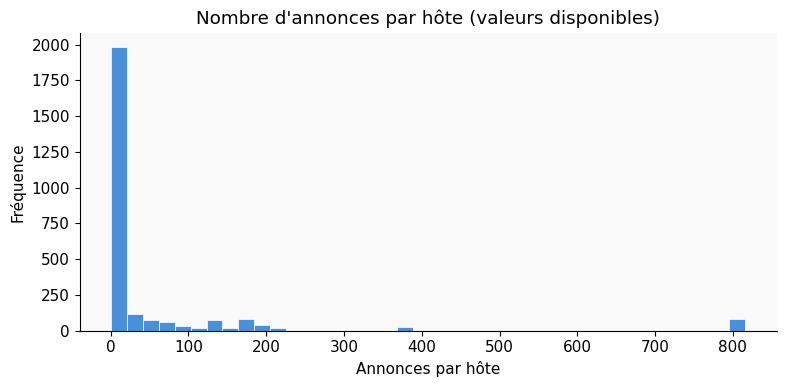

→ Interprétation : si la distribution est très asymétrique à droite,
  quelques hôtes concentrent beaucoup d'annonces (profil professionnel).

=== availability_365 ===
Nature : quantitative (0 à 365 jours)
  Min    : 0
  Max    : 365
  Médiane: 183.0
  Moyenne: 174.7
  Dont −1 (non dispo) : 0


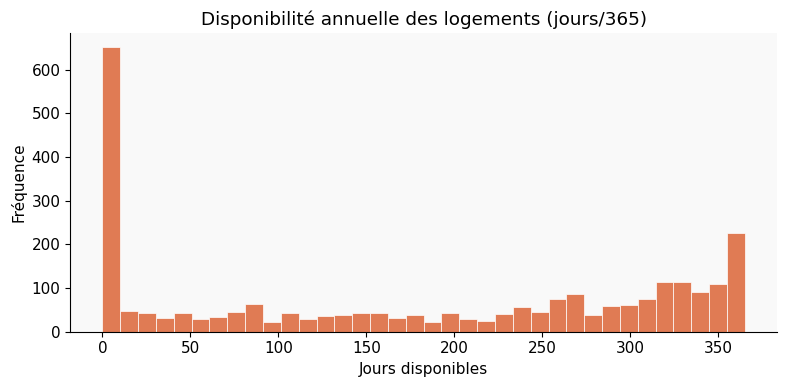

→ Interprétation : un pic vers 365 signale des logements quasi-permanents
  (usage touristique intensif). Un pic vers 0 = logements peu disponibles.

=== host_response_rate_num ===
Nature : quantitative (taux en %, 0 à 100)
  Min    : -1.0
  Max    : 100.0
  Médiane: 99.0
  Moyenne: 68.0
  Dont −1 (non dispo) : 681


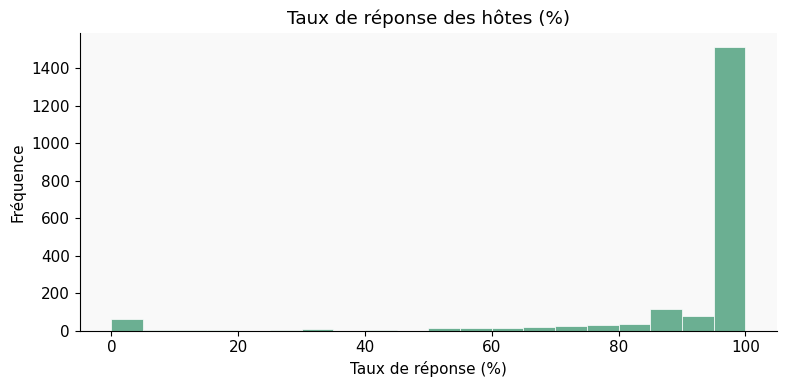


=== room_type_code ===
Nature : catégorielle nominale (codes entiers sans ordre logique)
room_type_code
Logement entier      297
Chambre partagée    2247
Hôtel                 81
Name: count, dtype: int64


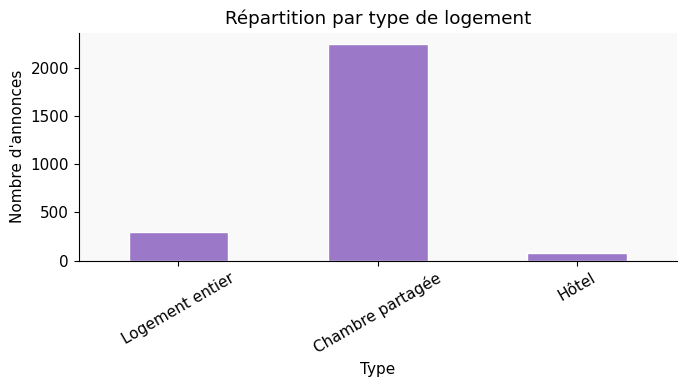

→ Attention : ne pas calculer de moyenne sur ce champ — les codes
  sont des étiquettes, pas des grandeurs ordonnées.

=== host_response_time_code ===
Nature : ordinale (0 = plus rapide → valeurs croissantes = plus lent)
host_response_time_code
Non dispo           681
< 1h               1356
Qq heures           244
Dans la journée     255
Qq jours             89
Name: count, dtype: int64


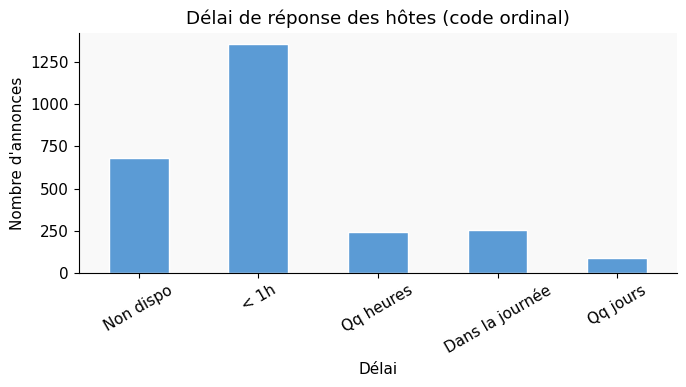


=== standardization_score ===
Nature : score trichotomique (−1 = non dispo, 0 = neutre, 1 = catalogue)
  Non dispo (−1) : 783 (29.8%)
  Neutre (0) : 792 (30.2%)
  Profil catalogue (1) : 1050 (40.0%)


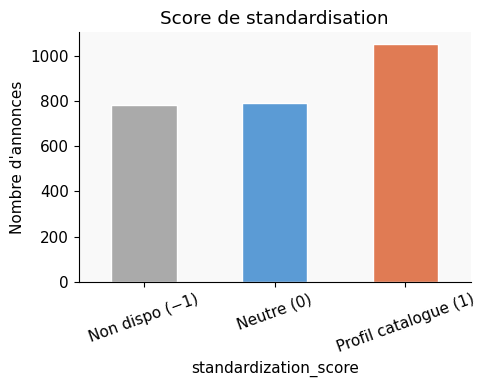

→ Les −1 sont des absences d'information (non calculés par le pipeline).
  Ils doivent être traités séparément dans les croisements (Bloc C).

=== neighborhood_impact_score ===
Nature : score trichotomique (−1 = non dispo, 0 = neutre, 1 = impact)
  Non dispo (−1) : 822 (31.3%)
  Neutre (0) : 799 (30.4%)
  Impact détecté (1) : 1004 (38.2%)


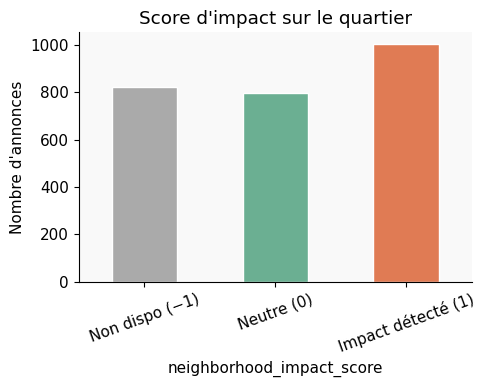


✅ Bloc B terminé — tous les graphiques sont sauvegardés.


In [4]:
# ============================================================
# BLOC B — Description univariée — ImmoVision 360
# ============================================================

# --- 1. IMPORTS ---
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import psycopg2
import warnings
warnings.filterwarnings("ignore")
from dotenv import load_dotenv

# Style global des graphiques
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f9f9f9",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
})

# ============================================================
# 2. CONNEXION POSTGRESQL ET CHARGEMENT
# ============================================================
conn = psycopg2.connect(
    host     = os.getenv("DB_HOST"),
    dbname   = os.getenv("DB_NAME"),
    user     = os.getenv("DB_USER"),
    password = os.getenv("DB_PASSWORD"),
    port     = os.getenv("DB_PORT"),
)

query = "SELECT * FROM elysee_tabular;"
df_raw = pd.read_sql(query, conn)
conn.close()

print(f"Table chargée : {df_raw.shape[0]} lignes, {df_raw.shape[1]} colonnes")
print(df_raw.dtypes)

# ============================================================
# 3. REMPLACEMENT DES VALEURS MANQUANTES PAR −1
# ============================================================
# Convention : −1 = "information non disponible".
# À distinguer du 0 métier (ex. disponibilité nulle = 0 jour,
# ce qui est une vraie valeur, pas une absence d'info).
df = df_raw.fillna(-1)

print("\nValeurs manquantes AVANT remplissage :")
print(df_raw.isnull().sum())
print("\nValeurs manquantes APRÈS remplissage (doit être 0 partout) :")
print(df.isnull().sum())

# ============================================================
# 4. DESCRIPTION UNIVARIÉE — une section par variable
# ============================================================

# ── 4.1 id (identifiant) ─────────────────────────────────────
print("\n=== id ===")
print("Nature : identifiant unique — pas de statistique métier.")
print(f"Nb lignes : {df['id'].nunique()} valeurs uniques sur {len(df)}")
# On ne trace pas d'histogramme sur un identifiant.

# ── 4.2 calculated_host_listings_count (quantitative) ────────
col = "calculated_host_listings_count"
s = df[col]
print(f"\n=== {col} ===")
print("Nature : quantitative (entier positif)")
print(f"  Min    : {s.min()}")
print(f"  Max    : {s.max()}")
print(f"  Médiane: {s.median()}")
print(f"  Moyenne: {s.mean():.1f}")
print(f"  Dont −1 (non dispo) : {(s == -1).sum()}")

fig, ax = plt.subplots(figsize=(8, 4))
s_valid = s[s >= 0]   # on exclut les −1 pour l'histogramme
ax.hist(s_valid, bins=40, color="#4A90D9", edgecolor="white", linewidth=0.5)
ax.set_title("Nombre d'annonces par hôte (valeurs disponibles)")
ax.set_xlabel("Annonces par hôte")
ax.set_ylabel("Fréquence")
plt.tight_layout()
plt.savefig("hist_host_listings.png", dpi=150)
plt.show()
print("→ Interprétation : si la distribution est très asymétrique à droite,")
print("  quelques hôtes concentrent beaucoup d'annonces (profil professionnel).")

# ── 4.3 availability_365 (quantitative) ───────────────────────
col = "availability_365"
s = df[col]
print(f"\n=== {col} ===")
print("Nature : quantitative (0 à 365 jours)")
print(f"  Min    : {s.min()}")
print(f"  Max    : {s.max()}")
print(f"  Médiane: {s.median()}")
print(f"  Moyenne: {s.mean():.1f}")
print(f"  Dont −1 (non dispo) : {(s == -1).sum()}")

fig, ax = plt.subplots(figsize=(8, 4))
s_valid = s[s >= 0]
ax.hist(s_valid, bins=36, color="#E07B54", edgecolor="white", linewidth=0.5)
ax.set_title("Disponibilité annuelle des logements (jours/365)")
ax.set_xlabel("Jours disponibles")
ax.set_ylabel("Fréquence")
plt.tight_layout()
plt.savefig("hist_availability.png", dpi=150)
plt.show()
print("→ Interprétation : un pic vers 365 signale des logements quasi-permanents")
print("  (usage touristique intensif). Un pic vers 0 = logements peu disponibles.")

# ── 4.4 host_response_rate_num (quantitative) ─────────────────
col = "host_response_rate_num"
s = df[col]
print(f"\n=== {col} ===")
print("Nature : quantitative (taux en %, 0 à 100)")
print(f"  Min    : {s.min()}")
print(f"  Max    : {s.max()}")
print(f"  Médiane: {s.median()}")
print(f"  Moyenne: {s.mean():.1f}")
print(f"  Dont −1 (non dispo) : {(s == -1).sum()}")

fig, ax = plt.subplots(figsize=(8, 4))
s_valid = s[s >= 0]
ax.hist(s_valid, bins=20, color="#6BAF92", edgecolor="white", linewidth=0.5)
ax.set_title("Taux de réponse des hôtes (%)")
ax.set_xlabel("Taux de réponse (%)")
ax.set_ylabel("Fréquence")
plt.tight_layout()
plt.savefig("hist_response_rate.png", dpi=150)
plt.show()

# ── 4.5 room_type_code (catégorielle nominale) ────────────────
col = "room_type_code"
s = df[col]
labels = {-1: "Non dispo", 0: "Chambre privée",
           1: "Logement entier", 2: "Chambre partagée", 3: "Hôtel"}
print(f"\n=== {col} ===")
print("Nature : catégorielle nominale (codes entiers sans ordre logique)")
counts = s.value_counts().sort_index()
print(counts.rename(index=labels))

fig, ax = plt.subplots(figsize=(7, 4))
counts_labeled = counts.rename(index=labels)
counts_labeled.plot(kind="bar", ax=ax, color="#9B79C8", edgecolor="white")
ax.set_title("Répartition par type de logement")
ax.set_xlabel("Type")
ax.set_ylabel("Nombre d'annonces")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("bar_room_type.png", dpi=150)
plt.show()
print("→ Attention : ne pas calculer de moyenne sur ce champ — les codes")
print("  sont des étiquettes, pas des grandeurs ordonnées.")

# ── 4.6 host_response_time_code (ordinale) ────────────────────
col = "host_response_time_code"
s = df[col]
labels_ord = {-1: "Non dispo", 0: "< 1h", 1: "Qq heures",
               2: "Dans la journée", 3: "Qq jours"}
print(f"\n=== {col} ===")
print("Nature : ordinale (0 = plus rapide → valeurs croissantes = plus lent)")
counts = s.value_counts().sort_index()
print(counts.rename(index=labels_ord))

fig, ax = plt.subplots(figsize=(7, 4))
counts.rename(index=labels_ord).plot(kind="bar", ax=ax,
                                      color="#5B9BD5", edgecolor="white")
ax.set_title("Délai de réponse des hôtes (code ordinal)")
ax.set_xlabel("Délai")
ax.set_ylabel("Nombre d'annonces")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("bar_response_time.png", dpi=150)
plt.show()

# ── 4.7 standardization_score (score trichotomique) ───────────
col = "standardization_score"
s = df[col]
labels_sc = {-1: "Non dispo (−1)", 0: "Neutre (0)", 1: "Profil catalogue (1)"}
print(f"\n=== {col} ===")
print("Nature : score trichotomique (−1 = non dispo, 0 = neutre, 1 = catalogue)")
counts = s.value_counts().sort_index()
total = len(s)
for val, label in labels_sc.items():
    n = counts.get(val, 0)
    print(f"  {label} : {n} ({100*n/total:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
counts.rename(index=labels_sc).plot(kind="bar", ax=ax,
                                     color=["#AAAAAA","#5B9BD5","#E07B54"],
                                     edgecolor="white")
ax.set_title("Score de standardisation")
ax.set_ylabel("Nombre d'annonces")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("bar_standardization.png", dpi=150)
plt.show()
print("→ Les −1 sont des absences d'information (non calculés par le pipeline).")
print("  Ils doivent être traités séparément dans les croisements (Bloc C).")

# ── 4.8 neighborhood_impact_score (score trichotomique) ────────
col = "neighborhood_impact_score"
s = df[col]
labels_ni = {-1: "Non dispo (−1)", 0: "Neutre (0)", 1: "Impact détecté (1)"}
print(f"\n=== {col} ===")
print("Nature : score trichotomique (−1 = non dispo, 0 = neutre, 1 = impact)")
counts = s.value_counts().sort_index()
total = len(s)
for val, label in labels_ni.items():
    n = counts.get(val, 0)
    print(f"  {label} : {n} ({100*n/total:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
counts.rename(index=labels_ni).plot(kind="bar", ax=ax,
                                     color=["#AAAAAA","#6BAF92","#E07B54"],
                                     edgecolor="white")
ax.set_title("Score d'impact sur le quartier")
ax.set_ylabel("Nombre d'annonces")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("bar_neighborhood_impact.png", dpi=150)
plt.show()

print("\n✅ Bloc B terminé — tous les graphiques sont sauvegardés.")